<a href="https://colab.research.google.com/github/dasakorol06-hue/AB-test/blob/main/AB_%D1%82%D0%B5%D1%81%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('website_ab_test.csv')
print(df.head())

         Theme  Click Through Rate  Conversion Rate  Bounce Rate  \
0  Light Theme            0.054920         0.282367     0.405085   
1  Light Theme            0.113932         0.032973     0.732759   
2   Dark Theme            0.323352         0.178763     0.296543   
3  Light Theme            0.485836         0.325225     0.245001   
4  Light Theme            0.034783         0.196766     0.765100   

   Scroll_Depth  Age   Location  Session_Duration Purchases Added_to_Cart  
0     72.489458   25    Chennai              1535        No           Yes  
1     61.858568   19       Pune               303        No           Yes  
2     45.737376   47    Chennai               563       Yes           Yes  
3     76.305298   58       Pune               385       Yes            No  
4     48.927407   25  New Delhi              1437        No            No  


Cтатистика по группам

In [7]:
print("Распределение по группам")
print(df['Theme'].value_counts())
print("Средние метрики по группам")
metrics = df.groupby('Theme').agg(
    users=('Theme', 'count'),
    conversion_rate=('Conversion Rate', 'mean'),
    bounce_rate=('Bounce Rate', 'mean'),
    session_duration=('Session_Duration', 'mean'),
    scroll_depth=('Scroll_Depth', 'mean')
).round(4)
print(metrics)

# Сегментация: конверсия по возрастным группам
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 100],
                         labels=['<25', '25-34', '35-49', '50+'])
print("Конверсия по возрасту и теме")
print(df.groupby(['Theme', 'Age_Group'])['Conversion Rate'].mean().unstack().round(3))

Распределение по группам
Theme
Dark Theme     514
Light Theme    486
Name: count, dtype: int64
Средние метрики по группам
             users  conversion_rate  bounce_rate  session_duration  \
Theme                                                                
Dark Theme     514           0.2513       0.5121          919.4825   
Light Theme    486           0.2555       0.4990          930.8333   

             scroll_depth  
Theme                      
Dark Theme        49.9264  
Light Theme       50.7352  
Конверсия по возрасту и теме
Age_Group      <25  25-34  35-49    50+
Theme                                  
Dark Theme   0.262  0.246  0.245  0.254
Light Theme  0.252  0.246  0.265  0.253


/tmp/ipykernel_2231/735473747.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Theme', 'Age_Group'])['Conversion Rate'].mean().unstack().round(3))


T-критерий

In [8]:
conv_light = df[df['Theme'] == 'Light Theme']['Conversion Rate']
conv_dark = df[df['Theme'] == 'Dark Theme']['Conversion Rate']
t_stat, p_value_ttest = stats.ttest_ind(conv_light, conv_dark)
print(f"T-stat: {t_stat:.4f}, P-value: {p_value_ttest:.6f}")

T-stat: 0.4745, P-value: 0.635252


BOOTSTRAP

In [10]:
n_bootstrap = 10000
diff_means = []

for _ in tqdm(range(n_bootstrap), desc="Bootstrap итерации"):
    sample_light = np.random.choice(conv_light, size=len(conv_light), replace=True)
    sample_dark = np.random.choice(conv_dark, size=len(conv_dark), replace=True)
    diff_means.append(np.mean(sample_dark) - np.mean(sample_light))

diff_means = np.array(diff_means)
ci_lower = np.percentile(diff_means, 2.5)
ci_upper = np.percentile(diff_means, 97.5)
p_value_bootstrap = (diff_means <= 0).mean()

print(f"Средняя разница (Dark - Light): {np.mean(diff_means):.6f}")
print(f"95% Доверительный интервал: [{ci_lower:.6f}; {ci_upper:.6f}]")
print(f"P-value: {p_value_bootstrap:.6f}")
if p_value_bootstrap < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Статистически значимой разницы нет")

Bootstrap итерации: 100%|██████████| 10000/10000 [00:01<00:00, 8948.35it/s]

Средняя разница (Dark - Light): -0.004215
95% Доверительный интервал: [-0.021500; 0.012860]
P-value: 0.682900
Статистически значимой разницы нет


Дашборд

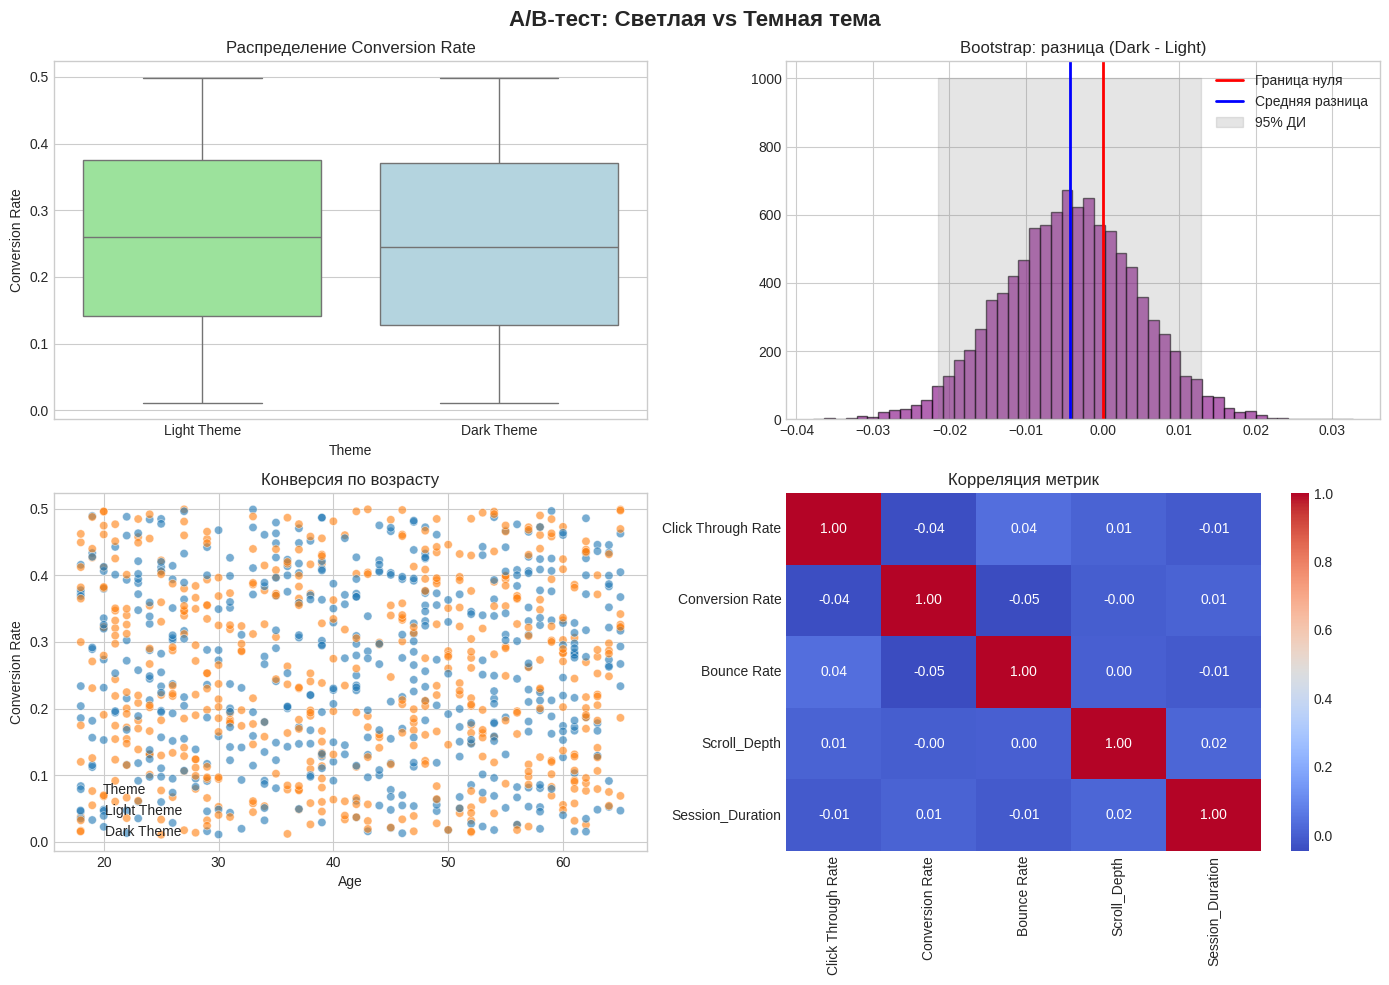

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('A/B-тест: Светлая vs Темная тема', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
sns.boxplot(x='Theme', y='Conversion Rate', data=df, ax=ax1, palette=['lightgreen', 'lightblue'])
ax1.set_title('Распределение Conversion Rate')

ax2 = axes[0, 1]
ax2.hist(diff_means, bins=50, color='purple', alpha=0.6, edgecolor='black')
ax2.axvline(x=0, color='red', linewidth=2, label='Граница нуля')
ax2.axvline(x=np.mean(diff_means), color='blue', linewidth=2, label='Средняя разница')
ax2.fill_betweenx([0, 1000], ci_lower, ci_upper, color='gray', alpha=0.2, label='95% ДИ')
ax2.set_title('Bootstrap: разница (Dark - Light)')
ax2.legend()

ax3 = axes[1, 0]
sns.scatterplot(x='Age', y='Conversion Rate', hue='Theme', data=df, ax=ax3, alpha=0.6)
ax3.set_title('Конверсия по возрасту')

ax4 = axes[1, 1]
corr = df[['Click Through Rate', 'Conversion Rate', 'Bounce Rate',
           'Scroll_Depth', 'Session_Duration']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax4)
ax4.set_title('Корреляция метрик')

plt.tight_layout()
plt.show()

Исходя из структуры этого датасета, можно построить выводы:

Гипотеза: Темная тема оформления увеличивает конверсию по сравнению со светлой.

Метрики: Конверсия (Conversion Rate), поведенческие метрики (Click Through Rate, Bounce Rate).

Метод: Bootstrap + t-критерий для справки.

Результаты:

По Conversion Rate статистически значимой разницы не обнаружено (p-value > 0.05, ДИ пересекает 0).

Рекомендации:

Решение о внедрении темной темы нельзя принимать на основе Conversion Rate — он не показывает значимого улучшения.

Для более точных выводов рекомендуется провести A/B-тест с большей выборкой или на другом сегменте аудитории.